<a href="https://colab.research.google.com/github/jqchen24-new/ml-zoomcamp/blob/main/08_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [7]:
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

Cloning into 'clothing-dataset-small'...
remote: Enumerating objects: 3839, done.
remote: Counting objects: 100% (400/400), done.
remote: Compressing objects: 100% (400/400), done.
remote: Total 3839 (delta 9), reused 385 (delta 0), pack-reused 3439 (from 1)
Receiving objects: 100% (3839/3839), 100.58 MiB | 37.14 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [ ]:
!ls

clothing-dataset-small	sample_data


## 8. Neural networks and deep learning

### 8.1 Fashion classification

Dataset:

- Full: https://github.com/alexeygrigorev/clothing-dataset
- Small: https://github.com/alexeygrigorev/clothing-dataset-small

Links:

https://cs231n.github.io/

!git clone git@github.com:alexeygrigorev/clothing-dataset-small.git

### 8.2 TensorFlow and Keras

- Installing TensorFlow
- Loading images

In [8]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [9]:
import tensorflow as tf
from tensorflow import keras

In [10]:
from tensorflow.keras.preprocessing.image import load_img

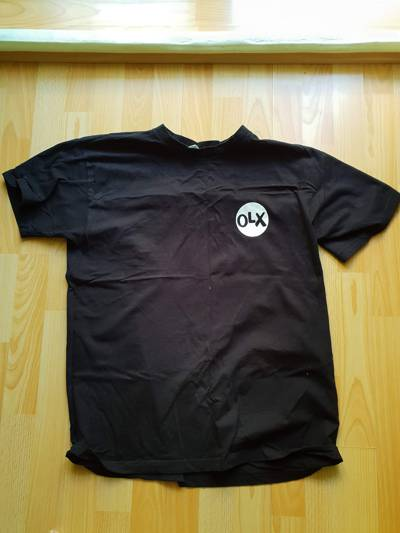

In [11]:
path = './clothing-dataset-small/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

In [12]:
img = load_img(fullname, target_size=(299, 299))

In [13]:
x = np.array(img)
x.shape

(299, 299, 3)

### 8.3 Pre-trained convolutional neural networks

- Imagenet dataset: https://www.image-net.org/
- Pre-trained models: https://keras.io/api/applications/

In [14]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [15]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# keras require X to be in a certain format where the first dimension is batch size
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [17]:
X = preprocess_input(X)
pred = model.predict(X)
decode_predictions(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n03595614', 'jersey', np.float32(0.68196356)),
  ('n02916936', 'bulletproof_vest', np.float32(0.038139977)),
  ('n04370456', 'sweatshirt', np.float32(0.034324735)),
  ('n03710637', 'maillot', np.float32(0.011354207)),
  ('n04525038', 'velvet', np.float32(0.0018453562))]]

### 8.4 Convolutional neural networks

- Types of layers: convolutional and dense
- Convolutional layers and filters
- Dense layers

There are more layers. Read here: https://cs231n.github.io/

### 8.5 Transfer learning

- Reading data with ImageDataGenerator
- Train Xception on smaller images (150x150)

(Better to run it with a GPU)

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
# This code creates a Keras image dataset loader from folders on disk.
# ImageDataGenerator(...) creates an image pipeline.
# preprocessing_function=preprocess_input applies the model-specific preprocessing to each image before training.
# flow_from_directory(...) reads images from a folder structure like this:

# clothing-dataset-small/
# └── train/
#     ├── class_1/
#     │   ├── img1.jpg
#     │   └── img2.jpg
#     ├── class_2/
#     │   ├── img3.jpg
#     │   └── img4.jpg

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [20]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [21]:
X, y = next(train_ds)

In [22]:
y[:5]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [23]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


This builds a transfer learning image classifier using Xception as the frozen feature extractor.

	•	Loads the pretrained Xception model
	•	weights='imagenet' means it starts with weights learned from ImageNet
	•	include_top=False removes Xception’s original classifier head
	•	input_shape=(150, 150, 3) means your images are 150×150 RGB

    •	Freezes the pretrained layers
	•	During training, only your new top layer will learn

#### What base looks like?

The base_model is Xception with include_top=False, so it does not output class predictions. It outputs a stack of **feature maps**.

For one image, base looks roughly like:

```
(height, width, channels)
```

and for a batch:

```
(batch_size, height, width, channels)
```

For example, it might be something like:

```
(batch_size, 5, 5, 2048)
```

That means:
- 5 x 5 = spatial grid
- 2048 = number of learned feature channels

Each of those 2048 channels is like a detector for some visual pattern.

#### What GlobalAveragePooling2D does

It takes each channel and averages across all spatial locations.

So if one channel is:
```python
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```
the average is:
```python
(1+2+3+4+5+6+7+8+9) / 9 = 5
```
It does this for every channel.

So
```python
(batch_size, 5, 5, 2048)
```

becomes
```python
(batch_size, 2048)
```

Each image is now represented by a single 2048-dimensional vector.


#### Why this is useful

A Dense layer expects a vector, not a 3D feature map.

So this step:
- compresses the convolution output
- keeps the most important channel-level information
- reduces the number of parameters a lot

Without it, you might need to flatten everything:

```python
keras.layers.Flatten()(base)
```

If base were shape (5, 5, 2048), flattening gives:
```python
5 * 5 * 2048 = 51200
```

That is much bigger than 2048, so your final Dense layer would have far more weights and be more likely to overfit.

In [24]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False



inputs = keras.Input(shape=(150, 150, 3))

# Passes the inputs through Xception
# training=False is important because it keeps layers like BatchNorm in inference mode while frozen
base = base_model(inputs, training=False)
# Converts the convolutional feature maps into one feature vector per image
vectors = keras.layers.GlobalAveragePooling2D()(base)

# Adds the final prediction layer with 10 outputs
# Right now this gives raw logits, not probabilities

#If you want probabilities directly, use: outputs = keras.layers.Dense(10, activation='softmax')(vectors)
# so this matches correctly with loss = keras.losses.CategoricalCrossentropy(from_logits=True) in the next cell
outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

# CategoricalCrossentropy(from_logits=True) → expects logits
loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [26]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 57s 409ms/step - accuracy: 0.6789 - loss: 1.2672 - val_accuracy: 0.7771 - val_loss: 0.8927
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8250 - loss: 0.5280 - val_accuracy: 0.7742 - val_loss: 0.9279
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8889 - loss: 0.3524 - val_accuracy: 0.8035 - val_loss: 0.8413
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9120 - loss: 0.2481 - val_accuracy: 0.8006 - val_loss: 0.8717
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9482 - loss: 0.1497 - val_accuracy: 0.7713 - val_loss: 0.8786
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9400 - loss: 0.1601 - val_accuracy: 0.8299 - val_loss: 0.8713
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9729 - loss: 0.0789 - val_accuracy: 0.8035 - val_loss: 0.9638
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9896 - loss: 0.0457 - val_accuracy: 0.8006 -

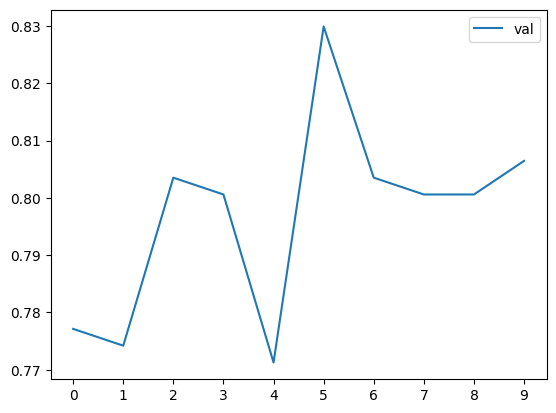

In [27]:
#plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()

### 8.6 Adjusting the learning rate

- What's the learning rate
- Trying different values

In [28]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [29]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 210ms/step - accuracy: 0.3680 - loss: 1.9192 - val_accuracy: 0.4692 - val_loss: 1.6390
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.5694 - loss: 1.3777 - val_accuracy: 0.5718 - val_loss: 1.2892
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.6389 - loss: 1.1381 - val_accuracy: 0.6452 - val_loss: 1.1016
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.6793 - loss: 0.9994 - val_accuracy: 0.6862 - val_loss: 0.9929
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.7050 - loss: 0.9062 - val_accuracy: 0.7097 - val_loss: 0.9118
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7275 - loss: 0.8383 - val_accuracy: 0.7361 - val_loss: 0.8526
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.7487 - loss: 0.7858 - val_accuracy: 0.7331 - val_loss: 0.8169
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.7568 - loss: 0.7435 - val_accuracy: 0

In [30]:
def charting(lr = [0.0001, 0.001, 0.01, 0.1]):
    for eta, hist in scores.items():
        if eta in lr:
            #plt.plot(hist['accuracy'], label=('train=%s' % lr))
            plt.plot(hist['val_accuracy'], label=('val=%s' % eta))

    plt.xticks(np.arange(10))
    plt.legend()

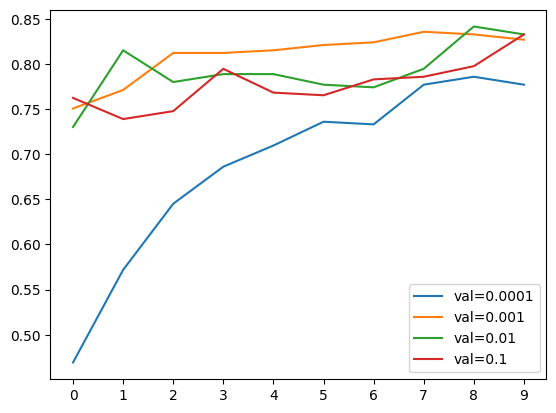

In [31]:
charting()

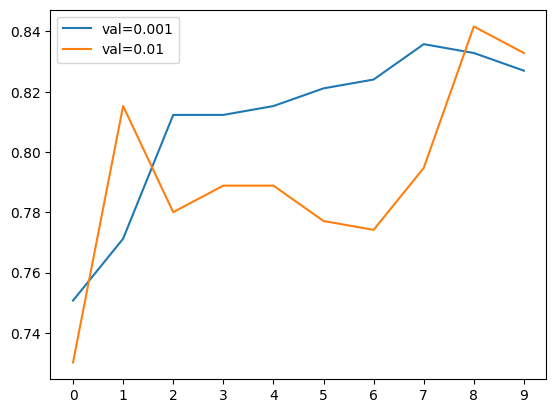

In [32]:
charting(lr = [0.01, 0.001])

In [33]:
learning_rate = 0.001

### 8.7 Checkpointing

- Saving the best model only from the different epochs
- Training a model with callbacks

In [34]:
model.save_weights('model_v1.weights.h5')

In [35]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [36]:
learning_rate = 0.001

model = make_model(learning_rate=learning_rate)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 219ms/step - accuracy: 0.6265 - loss: 1.1161 - val_accuracy: 0.7537 - val_loss: 0.7399
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.7839 - loss: 0.6345 - val_accuracy: 0.7947 - val_loss: 0.6233
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8289 - loss: 0.5104 - val_accuracy: 0.8211 - val_loss: 0.5722
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8667 - loss: 0.4301 - val_accuracy: 0.8152 - val_loss: 0.5658
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.8830 - loss: 0.3797 - val_accuracy: 0.7918 - val_loss: 0.5602
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9081 - loss: 0.3267 - val_accuracy: 0.8182 - val_loss: 0.5254
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9221 - loss: 0.2880 - val_accuracy: 0.8240 - val_loss: 0.5255
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9302 - loss: 0.2635 - val_accuracy: 0.8152 

### 8.8 Adding more layers

- Adding one inner dense layer
- Experimenting with different sizes of inner layer

In [37]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    ## added inner dense layer
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    outputs = keras.layers.Dense(10)(inner)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [38]:
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 31s 233ms/step - accuracy: 0.5795 - loss: 1.3138 - val_accuracy: 0.7097 - val_loss: 0.9173
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.7386 - loss: 0.8145 - val_accuracy: 0.7243 - val_loss: 0.8007
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.7767 - loss: 0.6667 - val_accuracy: 0.7801 - val_loss: 0.6990
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8188 - loss: 0.5445 - val_accuracy: 0.7859 - val_loss: 0.6466
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8546 - loss: 0.4537 - val_accuracy: 0.8035 - val_loss: 0.6076
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.8853 - loss: 0.3895 - val_accuracy: 0.8006 - val_loss: 0.5884
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.8983 - loss: 0.3359 - val_accuracy: 0.8240 - val_loss: 0.5669
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9185 - loss: 0.2861 - val_accuracy: 0.80

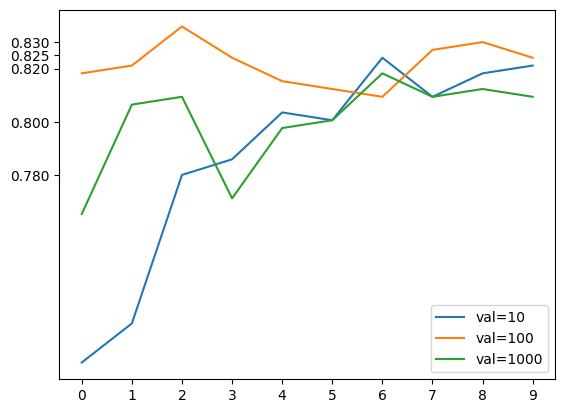

In [39]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % size))

plt.xticks(np.arange(10))
plt.yticks([0.78, 0.80, 0.82, 0.825, 0.83])
plt.legend()

In [40]:
size = 100

#### 8.9 Regularization and dropout

- Regularizing by freezing a part of the network
- Adding dropout to our model
- Experimenting with different values

In [41]:
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    ## added dropout layer
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [42]:
learning_rate = 0.001
size = 100

scores = {}

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(
        learning_rate=learning_rate,
        size_inner=size,
        droprate=droprate
    )

    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 31s 222ms/step - accuracy: 0.6509 - loss: 1.0025 - val_accuracy: 0.7801 - val_loss: 0.6729
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8250 - loss: 0.5126 - val_accuracy: 0.8299 - val_loss: 0.5849
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8836 - loss: 0.3468 - val_accuracy: 0.8240 - val_loss: 0.5505
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9198 - loss: 0.2587 - val_accuracy: 0.8240 - val_loss: 0.5687
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9488 - loss: 0.1777 - val_accuracy: 0.8328 - val_loss: 0.5427
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9707 - loss: 0.1325 - val_accuracy: 0.8211 - val_loss: 0.5900
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9876 - loss: 0.0817 - val_accuracy: 0.8211 - val_loss: 0.6044
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9863 - loss: 0.0709 - val_accuracy: 0.81

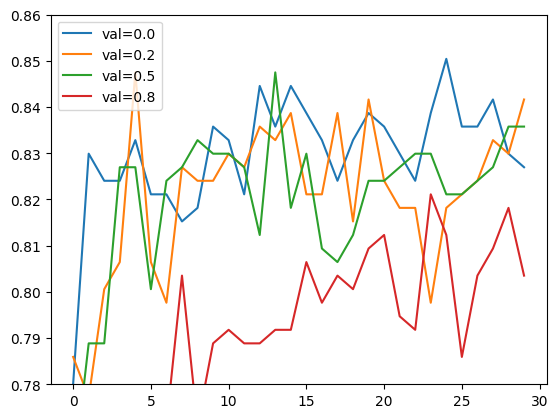

In [48]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % droprate))

plt.ylim(0.78, 0.86)
plt.legend()

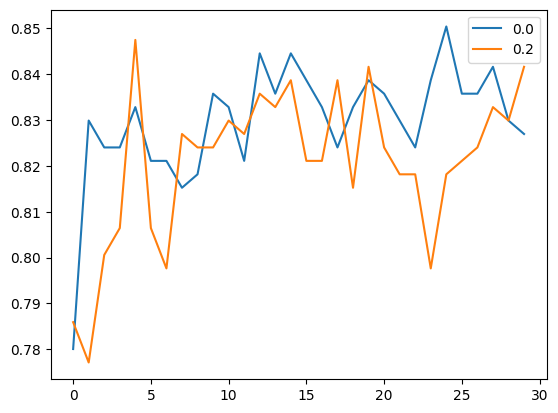

In [49]:
hist = scores[0.0]
plt.plot(hist['val_accuracy'], label=0.0)

hist = scores[0.2]
plt.plot(hist['val_accuracy'], label=0.2)

plt.legend()
#plt.plot(hist['accuracy'], label=('val=%s' % droprate))

### 8.10 Data augmentation

- Different data augmentations
- Training a model with augmentations
- How to select data augmentations?

In [53]:
ImageDataGenerator

keras.src.legacy.preprocessing.image.ImageDataGenerator

In [54]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    vertical_flip=True,
    shear_range = 1.0,
    height_shift_range = 1.0,
    width_shift_range = 1.0
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [ ]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 47s 395ms/step - accuracy: 0.5795 - loss: 1.2487 - val_accuracy: 0.7243 - val_loss: 0.8059
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.7076 - loss: 0.8612 - val_accuracy: 0.7390 - val_loss: 0.6935
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 245ms/step - accuracy: 0.7529 - loss: 0.7334 - val_accuracy: 0.7683 - val_loss: 0.6493
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 243ms/step - accuracy: 0.7800 - loss: 0.6362 - val_accuracy: 0.7713 - val_loss: 0.6988
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 241ms/step - accuracy: 0.8074 - loss: 0.5689 - val_accuracy: 0.7859 - val_loss: 0.6306
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 234ms/step - accuracy: 0.8194 - loss: 0.5230 - val_accuracy: 0.7742 - val_loss: 0.6321
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 241ms/step - accuracy: 0.8422 - loss: 0.4672 - val_accuracy: 0.7859 - val_loss: 0.6178
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 240ms/step - accuracy: 0.8550 - loss: 0.4351 - val_accu

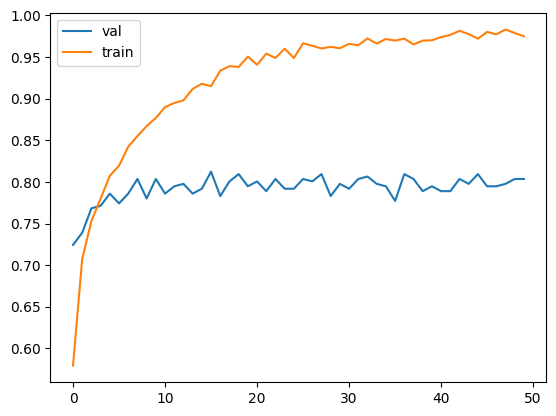

In [56]:
hist = history.history
plt.plot(hist['val_accuracy'], label='val')
plt.plot(hist['accuracy'], label='train')

plt.legend()

### 8.11 Training a larger model

Train a 299x299 model

In [57]:
def make_model(input_size=150, learning_rate=0.01, size_inner=100,
               droprate=0.5):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [58]:
input_size = 299

In [59]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(input_size, input_size),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(input_size, input_size), ## input size
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [60]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [61]:
learning_rate = 0.0005
size = 100
droprate = 0.2

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.5894 - loss: 1.2960

96/96 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.7148 - loss: 0.9026 - val_accuracy: 0.8504 - val_loss: 0.4992
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.8397 - loss: 0.4942

96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 295ms/step - accuracy: 0.8488 - loss: 0.4666 - val_accuracy: 0.8622 - val_loss: 0.4196
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8692 - loss: 0.3932

96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 304ms/step - accuracy: 0.8677 - loss: 0.3865 - val_accuracy: 0.8710 - val_loss: 0.3803
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 339ms/step - accuracy: 0.8960 - loss: 0.3235 - val_accuracy: 0.8651 - val_loss: 0.3853
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9174 - loss: 0.2582

96/96 ━━━━━━━━━━━━━━━━━━━━ 34s 352ms/step - accuracy: 0.9091 - loss: 0.2782 - val_accuracy: 0.8739 - val_loss: 0.3567
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9165 - loss: 0.2663

96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 339ms/step - accuracy: 0.9166 - loss: 0.2629 - val_accuracy: 0.8886 - val_loss: 0.3557
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 342ms/step - accuracy: 0.9201 - loss: 0.2369 - val_accuracy: 0.8827 - val_loss: 0.3933
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 339ms/step - accuracy: 0.9322 - loss: 0.2110 - val_accuracy: 0.8651 - val_loss: 0.3747
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 341ms/step - accuracy: 0.9377 - loss: 0.1946 - val_accuracy: 0.8710 - val_loss: 0.3643
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 35s 360ms/step - accuracy: 0.9433 - loss: 0.1786 - val_accuracy: 0.8856 - val_loss: 0.3579
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 339ms/step - accuracy: 0.9469 - loss: 0.1603 - val_accuracy: 0.8827 - val_loss: 0.3721
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 342ms/step - accuracy: 0.9547 - loss: 0.1451 - val_accuracy: 0.8827 - val_loss: 0.3670
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 341ms/step - accuracy: 0.9573 - loss: 0.1415 - val_accuracy: 0

96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 344ms/step - accuracy: 0.9902 - loss: 0.0513 - val_accuracy: 0.8915 - val_loss: 0.4021
Epoch 26/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 340ms/step - accuracy: 0.9905 - loss: 0.0496 - val_accuracy: 0.8739 - val_loss: 0.4356
Epoch 27/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 343ms/step - accuracy: 0.9919 - loss: 0.0453 - val_accuracy: 0.8856 - val_loss: 0.4203
Epoch 28/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 341ms/step - accuracy: 0.9909 - loss: 0.0442 - val_accuracy: 0.8886 - val_loss: 0.4205
Epoch 29/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 341ms/step - accuracy: 0.9954 - loss: 0.0357 - val_accuracy: 0.8915 - val_loss: 0.4333
Epoch 30/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 341ms/step - accuracy: 0.9932 - loss: 0.0380 - val_accuracy: 0.8915 - val_loss: 0.4231
Epoch 31/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 340ms/step - accuracy: 0.9948 - loss: 0.0341 - val_accuracy: 0.8915 - val_loss: 0.4354
Epoch 32/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 340ms/step - accuracy: 0.9967 - loss: 0.0295 - val_accuracy

96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 343ms/step - accuracy: 0.9951 - loss: 0.0252 - val_accuracy: 0.8974 - val_loss: 0.4483
Epoch 38/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 340ms/step - accuracy: 0.9971 - loss: 0.0222 - val_accuracy: 0.8915 - val_loss: 0.4795
Epoch 39/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 348ms/step - accuracy: 0.9971 - loss: 0.0215 - val_accuracy: 0.8798 - val_loss: 0.4706
Epoch 40/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 32s 338ms/step - accuracy: 0.9977 - loss: 0.0184 - val_accuracy: 0.8944 - val_loss: 0.4766
Epoch 41/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9970 - loss: 0.0157

96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 344ms/step - accuracy: 0.9990 - loss: 0.0153 - val_accuracy: 0.9003 - val_loss: 0.4735
Epoch 42/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 342ms/step - accuracy: 0.9990 - loss: 0.0151 - val_accuracy: 0.8915 - val_loss: 0.4874
Epoch 43/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 32s 338ms/step - accuracy: 0.9987 - loss: 0.0147 - val_accuracy: 0.8827 - val_loss: 0.5035
Epoch 44/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 339ms/step - accuracy: 0.9993 - loss: 0.0144 - val_accuracy: 0.8798 - val_loss: 0.4975
Epoch 45/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 340ms/step - accuracy: 0.9984 - loss: 0.0152 - val_accuracy: 0.8886 - val_loss: 0.5090
Epoch 46/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 342ms/step - accuracy: 0.9993 - loss: 0.0126 - val_accuracy: 0.8827 - val_loss: 0.5148
Epoch 47/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 341ms/step - accuracy: 0.9987 - loss: 0.0145 - val_accuracy: 0.8798 - val_loss: 0.5158
Epoch 48/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 340ms/step - accuracy: 0.9987 - loss: 0.0117 - val_accuracy

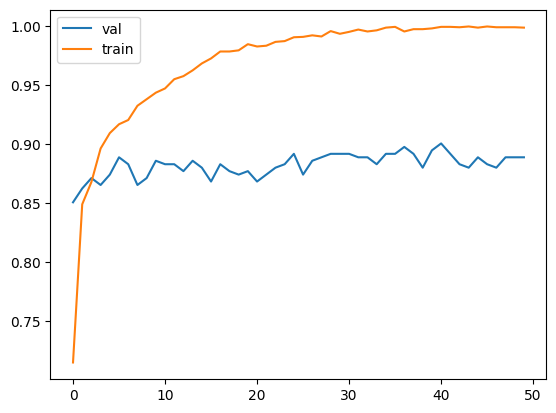

In [65]:
hist = history.history
plt.plot(hist['val_accuracy'], label='val')
plt.plot(hist['accuracy'], label='train')

plt.legend()

### 8.12 Using the model

- Loading the model
- Evaluating the model
- Getting predictions

In [66]:
import tensorflow as tf
from tensorflow import keras

In [67]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.applications.xception import preprocess_input

In [68]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './clothing-dataset-small/test',
    target_size=(299, 299),
    batch_size=32,
    shuffle=False
)

Found 372 images belonging to 10 classes.


In [69]:
model = keras.models.load_model('/content/xception_v4_1_41_0.900.h5')

In [70]:
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.9059 - loss: 0.3029


[0.30292195081710815, 0.9059139490127563]

In [75]:
path = 'clothing-dataset-small/test/pants/c8d21106-bbdb-4e8d-83e4-bf3d14e54c16.jpg'

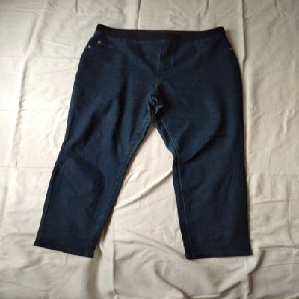

In [76]:
img = load_img(path, target_size=(299, 299))
img

In [77]:
import numpy as np
x = np.array(img)
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [78]:
X = preprocess_input(X)

In [79]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [80]:
classes = [
    'dress',
    'hat',
    'longsleeve',
    'outwear',
    'pants',
    'shirt',
    'shoes',
    'shorts',
    'skirt',
    't-shirt'
]

In [81]:
dict(zip(classes, pred[0]))

{'dress': np.float32(-5.974336),
 'hat': np.float32(-6.9842315),
 'longsleeve': np.float32(-2.3480515),
 'outwear': np.float32(-3.2839355),
 'pants': np.float32(12.499713),
 'shirt': np.float32(-2.6647074),
 'shoes': np.float32(-5.9415436),
 'shorts': np.float32(3.489059),
 'skirt': np.float32(-6.157362),
 't-shirt': np.float32(-5.8207045)}